In [1]:
import numpy as np

import dasly
from dasly.fitting.hyperbola_fitter import (
    fit_multiple_hyperbolas_least_squares,
    derive_hyperbola_metrics,
)
from dasly.detection.ht_lines import (
    compute_hough_theta,
    compute_hough_line_length,
)
from dasly.execution.box_saver import build_box_df
from dasly.loader.fsearcher import parse_file_path


# Parameters


In [2]:
file_paths = [
    '../data/svalbard/20220822/dphi/122539.hdf5',
    '../data/svalbard/20220822/dphi/122549.hdf5',
    '../data/svalbard/20220822/dphi/122559.hdf5',
]

s_start, s_end = 5_000, 115_000  # Start and end channel indices
f_min, f_max = 15, 25  # Hz
v_min, v_max = 1_484, 1_4844  # m/s
rms_window_size = 0.5  # Window size for RMS calculation in seconds
new_size = (640, 640)  # New size for resizing (width, height)
binary_quantile = 0.95  # Quantile for binary transformation
binary_by_channel = True  # Apply binary transformation by channel
dx = 1.0213001907746815  # Channel spacing in meters
target_velocity = 1_750  # Target velocity in m/s for HT parameters
hough_lines_rho = 1  # Distance resolution of the accumulator in pixels
hough_lines_velocity_res = 100  # Velocity resolution in m/s
hough_lines_len_m, hough_lines_len_s = None, 2.5
hough_lines_threshold_factor = 0.75  # Threshold factor for Hough transform
hough_lines_min_line_length_factor = 1
hough_lines_max_line_gap_factor = 0.2
velocity_low, velocity_high = 1_000, 5_000
single_linkage_clustering_epsilon_factor = 1  # Epsilon in seconds
single_linkage_clustering_trim_prop = 0.1  # Trim proportion
pair_grouping_threshold = 80  # Threshold for pair grouping
hyperbolas_num_points = 10  # Number of binary transformed points preserved
hyperbolas_by_channel = True  # Binary transformed points by channel


# Detection


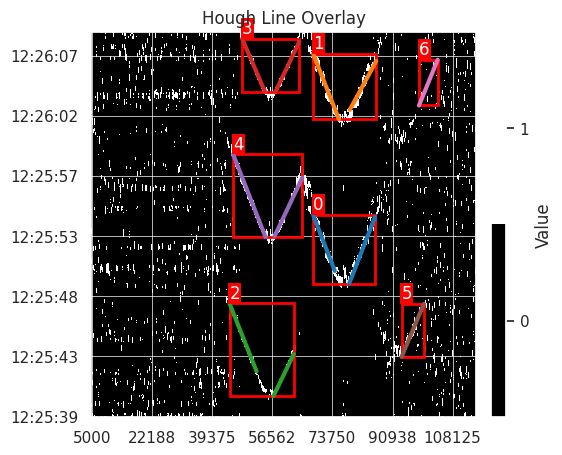

In [3]:
das_rms = (
    dasly.DASArray()
    .load(file_paths=file_paths, s_start=s_start, s_end=s_end)
    .fk_filter_real(f_min=f_min, f_max=f_max, v_min=v_min, v_max=v_max)
    .rms(window_size_second=rms_window_size)
)

new_dt = 10 * len(file_paths) / new_size[0]  # seconds
new_ds = (s_end - s_start) / new_size[1]  # seconds

# Precompute values for Hough transform
theta = compute_hough_theta(
    dt=new_dt,
    ds=new_ds,
    dx=dx,
    target_velocity=target_velocity,
    velocity_res=hough_lines_velocity_res
)

# Calculate the length of the expected lines in the image. This is used to
# calculate the threshold, minLineLength and maxLineGap parameters.
line_length = compute_hough_line_length(
    dt=new_dt,
    ds=new_ds,
    dx=dx,
    target_velocity=target_velocity,
    len_m=hough_lines_len_m,
    len_s=hough_lines_len_s,
)

threshold = int(hough_lines_threshold_factor * line_length)
minLineLength = hough_lines_min_line_length_factor * line_length
maxLineGap = hough_lines_max_line_gap_factor * line_length

das = (
    das_rms
    .resize_cv2(new_size=new_size)
    .binary_transform(
        quantile=binary_quantile,
        by_channel=binary_by_channel
    )
    .hough_lines(
        rho=hough_lines_rho,
        theta=theta,
        threshold=threshold,
        minLineLength=minLineLength,
        maxLineGap=maxLineGap
    )
    .filter_lines_by_velocity(
        velocity_low=velocity_low,
        velocity_high=velocity_high
    )
    .perform_single_linkage_clustering(
        epsilon=single_linkage_clustering_epsilon_factor * (1 / new_dt),
        trim_prop=single_linkage_clustering_trim_prop
    )
    .group_lines_by_pairs(
        threshold=pair_grouping_threshold,
        target_velocity=target_velocity
    )
    .build_boxes_from_lines()
)

fig, ax = das.plot(
    figsize=(5, 5),
    colorbar=True,
    title='Hough Line Overlay',
    xlabel='',
    ylabel='',
    show=True,
    lines=(
        das.meta.lines
        .loc[:, ['x1', 'y1', 'x2', 'y2']]
        .to_numpy()),
    linestyle='-',
    lineclusters=das.meta.lines['pair_group'].to_list(),
)

dasly.add_boxes(fig, das.meta.boxesn, num_boxes=True)


# Detection Boxes Information


In [4]:
hyperbolas = fit_multiple_hyperbolas_least_squares(
    array=das_rms,
    boxesn=das.meta.boxesn,
    num_points=hyperbolas_num_points,
    by_channel=hyperbolas_by_channel
)

hyper_metrics = derive_hyperbola_metrics(
    hyperbolas=hyperbolas,
    ds=das_rms.meta.ds,
    dx=das_rms.meta.dx
)

additional_hyper = {
    'source_distance': hyper_metrics['source_distance'],
    'hyper_rmse_norm': hyper_metrics['hyper_rmse_norm'],
    'hyper_mae_norm': hyper_metrics['hyper_mae_norm'],
}

exp_path, yyyymmdd, hhmmss, hhmmss_hdf5 = parse_file_path(file_paths[0])
chunk = f'{yyyymmdd}T{hhmmss}'
additional_hough = (
    das.meta.lines
    .groupby('pair_group')
    .agg(
        velocity=('velocity', lambda x: np.mean(np.abs(x))),
        velocity_std=('velocity_std', 'mean'),
        num_lines=('num_lines', 'sum'),
        sides=('pair_group', 'size')
    )
    .to_dict(orient='list')
)

boxes_df = build_box_df(
    boxesp=das.meta.boxesp,
    boxesn=das.meta.boxesn,
    chunk=chunk,
    chunk_size=len(file_paths),
    additional={**additional_hyper, **additional_hough}
)

boxes_df


,s1,t1,s2,t2,x1n,y1n,x2n,y2n,chunk,chunk_size,source_distance,hyper_rmse_norm,hyper_mae_norm,velocity,velocity_std,num_lines,sides
0,68151.171875,2022-08-22 12:25:49.343188524+00:00,85826.635742,2022-08-22 12:25:54.678588867+00:00,0.575000,0.345313,0.735938,0.523438,20220822T122539,3,2929.309269,0.076044,0.046722,1450.131507,34.30,13,2
1,68151.171875,2022-08-22 12:26:02.120068312+00:00,86169.848633,2022-08-22 12:26:07.221459866+00:00,0.575000,0.771875,0.739062,0.942187,20220822T122539,3,3488.247649,0.105433,0.058962,1755.744083,127.35,16,2
2,44297.875977,2022-08-22 12:25:40.591259718+00:00,62659.765625,2022-08-22 12:25:47.798730373+00:00,0.357812,0.053125,0.525000,0.293750,20220822T122539,3,354.087977,0.135425,0.077558,1655.083023,11.35,7,2
3,47901.611328,2022-08-22 12:26:04.226147413+00:00,64204.223633,2022-08-22 12:26:08.391503811+00:00,0.390625,0.842187,0.539062,0.981250,20220822T122539,3,2899.673018,0.050434,0.026463,1700.140595,59.60,10,2
4,45327.514648,2022-08-22 12:25:52.946923733+00:00,65062.255859,2022-08-22 12:25:59.405566454+00:00,0.367188,0.465625,0.546875,0.681250,20220822T122539,3,1626.911735,0.069388,0.033090,1620.606406,155.70,9,2
5,93377.319336,2022-08-22 12:25:43.633373976+00:00,99726.757812,2022-08-22 12:25:47.751928806+00:00,0.804688,0.154688,0.862500,0.292187,20220822T122539,3,0.502568,0.171019,0.098617,1574.504461,59.10,5,1
6,98353.906250,2022-08-22 12:26:03.196508884+00:00,103673.706055,2022-08-22 12:26:06.753442287+00:00,0.850000,0.807813,0.898438,0.926562,20220822T122539,3,113466.626134,0.308134,0.267051,1527.470899,0.00,1,1
